# Triangle plots for subluminal chains, constant $c_s^2$, with CMB lensing and DES

In [2]:
import numpy as np
import getdist
from getdist import plots

import utils

In [3]:
indices = list(range(79, 83)) + [76, 84]
chains = {}
for i in indices:
    chains[i] = utils.load_chain(i, burn_in=0.6, smooth_2D=0.3)

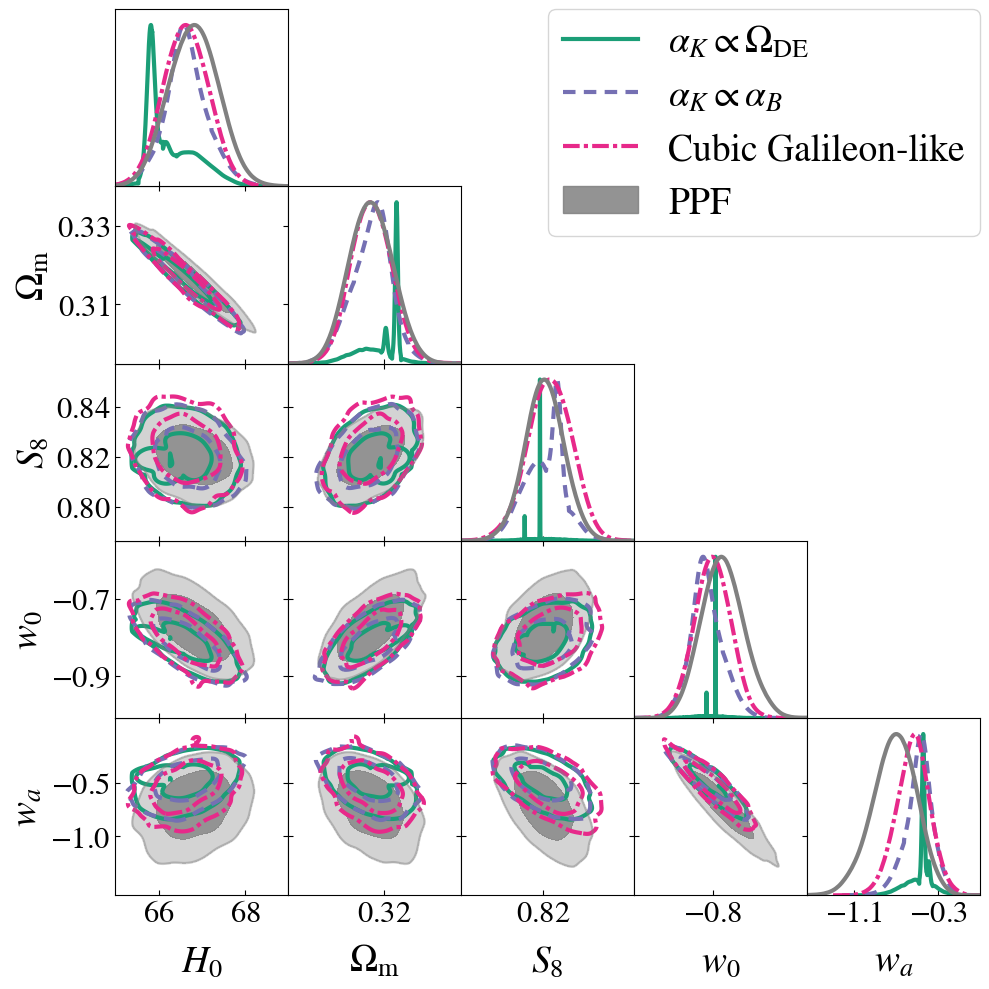

In [4]:
p = plots.get_subplot_plotter()
p.settings.axes_fontsize=25
p.settings.axes_labelsize=30
p.settings.legend_fontsize=30
p.triangle_plot(
    [chains[79], chains[81], chains[82], chains[76]],
    ["H0", "omegam", "S8", "w", "wa"],
    filled=[False, False, False, True],
    contour_colors=[utils.colors[0], utils.colors[2], utils.colors[3], "gray"],
    contour_lws=3,
    contour_ls=["-", "--", "-.", "-"],
    legend_labels=["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like", "PPF"],
    legend_loc="upper right",
    param_limits={"w": [-1.01, -0.55], "wa": [-1.55, 0.1], "H0": [65, 69], "omegam": [0.295, 0.34]}
)
p.fig.savefig("plots/triangle_ds2_subluminal_mg.pdf", bbox_inches="tight")

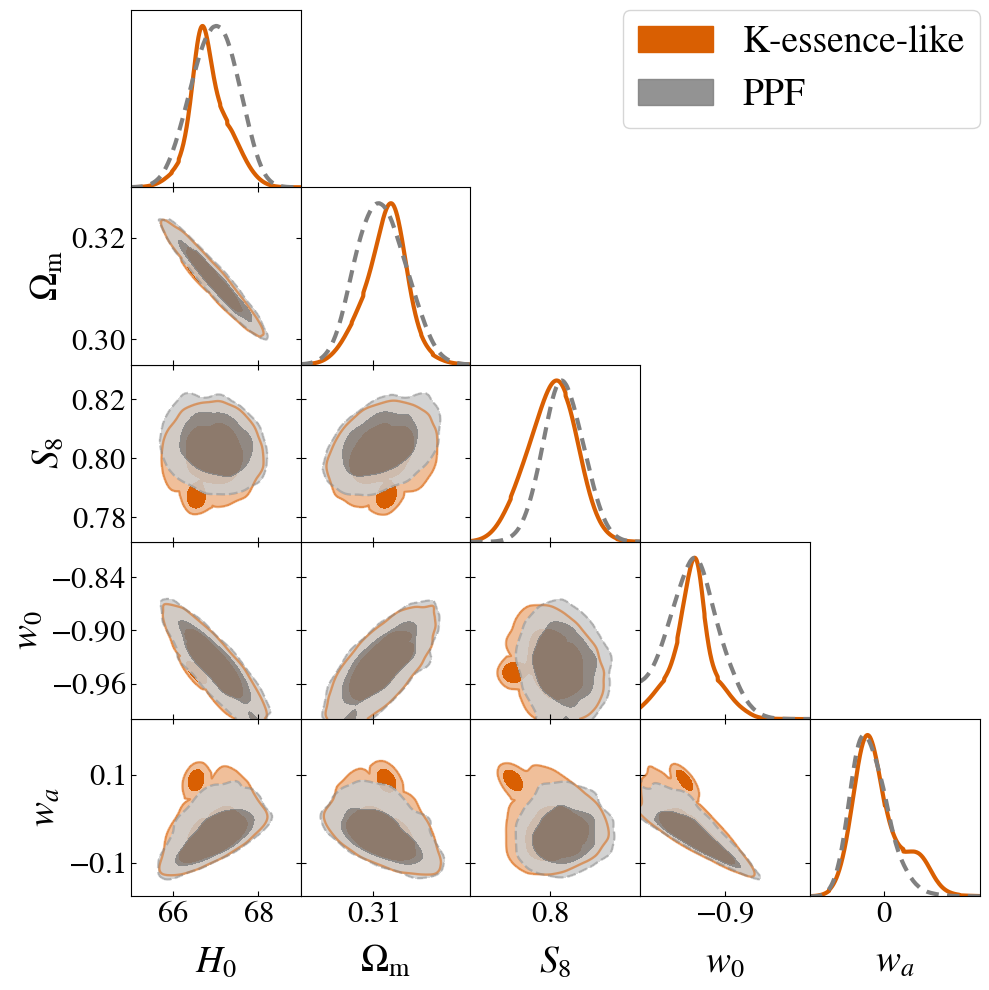

In [5]:
p = plots.get_subplot_plotter()
p.settings.axes_fontsize=25
p.settings.axes_labelsize=30
p.settings.legend_fontsize=30
p.triangle_plot(
    [chains[80], chains[84]],
    ["H0", "omegam", "S8", "w", "wa"],
    filled=[True, True],
    contour_colors=[utils.colors[1], "gray"],
    contour_lws=3,
    contour_ls=["-", "--", "-.", "-"],
    legend_labels=["K-essence-like", "PPF"],
    legend_loc="upper right",
    param_limits={"w": [-1, -0.8], "H0": [65, 69], "omegam": [0.295, 0.33]}
)
# p.fig.text(0.3, 1.01, "Data: Planck + DESI + DES-Dovekie", fontsize=20)
p.fig.savefig("plots/triangle_ds2_subluminal_mg_kessence.pdf", bbox_inches="tight")

In [6]:
# Getting numbers
for i, chain in chains.items():
    try: print(f"{i}: {chain.getInlineLatex('S8')}, {chain.getInlineLatex('w')}, {chain.getInlineLatex('wa')}, {chain.getInlineLatex('cs2_0', limit=2)}")
    except Exception: print(f"{i}: {chain.getInlineLatex('S8')}, {chain.getInlineLatex('w')}, {chain.getInlineLatex('wa')}")

79: S_8 = 0.8191^{+0.0077}_{-0.0069}, w_0 = -0.805^{+0.016}_{-0.031}, w_a = -0.467^{+0.10}_{-0.084}, c_s^2 < 0.837


80: S_8 = 0.8005^{+0.0094}_{-0.0080}, w_0 = -0.938\pm 0.024, w_a = -0.015^{+0.035}_{-0.071}, c_s^2 = ---


81: S_8 = 0.8208\pm 0.0082, w_0 = -0.818^{+0.038}_{-0.044}, w_a = -0.48^{+0.13}_{-0.11}, c_s^2 = ---


82: S_8 = 0.8227\pm 0.0092, w_0 = -0.802\pm 0.049, w_a = -0.54\pm 0.16, c_s^2 = ---


76: S_8 = 0.8206\pm 0.0081, w_0 = -0.774^{+0.053}_{-0.061}, w_a = -0.72^{+0.23}_{-0.19}, c_s^2 = ---


84: S_8 = 0.8046\pm 0.0075, w_0 = -0.937\pm 0.030, w_a = -0.033^{+0.036}_{-0.050}, c_s^2 = ---


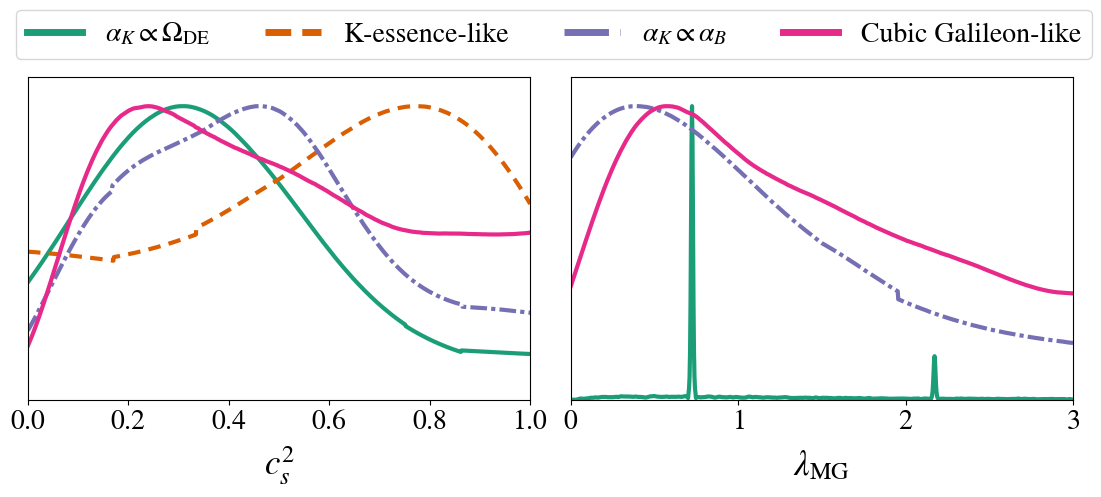

In [7]:
p = plots.get_subplot_plotter(width_inch=11, subplot_size_ratio=4/5)
p.settings.axes_fontsize=20
p.settings.axes_labelsize=25
p.settings.legend_fontsize=20
labels = ["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "K-essence-like", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like"]
p.plots_1d(
    [chains[79], chains[80], chains[81], chains[82]],
    ["cs2_0", "alpha_K_0"],
    colors=utils.colors,
    lws=3,
    ls=["-", "--", "-.", "-"],
    nx=2,
    legend_labels=[],
    param_limits={"w": [-1.01, -0.55], "wa": [-1.55, 0.1], "H0": [65, 69], "omegam": [0.295, 0.34]}
)

from matplotlib.lines import Line2D

handles = [
    Line2D([], [], linewidth=5, linestyle="-",  color=utils.colors[0]),
    Line2D([], [], linewidth=5, linestyle="--", color=utils.colors[1]),
    Line2D([], [], linewidth=5, linestyle="-.", color=utils.colors[2]),
    Line2D([], [], linewidth=5, linestyle="-",  color=utils.colors[3]),
]

# place legend relative to the figure (x,y in figure coordinates)
p.fig.legend(handles, labels,
             loc="upper center",
             ncol=4,
             fontsize=20,
             bbox_to_anchor=(0.508, 1.15),
             bbox_transform=p.fig.transFigure,
             frameon=True)

p.fig.savefig("plots/lambda_mg_cs2_subluminal_ds2.pdf", bbox_inches="tight")